<h1>Week 01. Text Data Essentials<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Week-01.-Introduction-to-Text-Data" data-toc-modified-id="Week-01.-Introduction-to-Text-Data-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Week 01. Introduction to Text Data</a></span></li><li><span><a href="#Loading-and-Inspecting-Data-with-Pandas" data-toc-modified-id="Loading-and-Inspecting-Data-with-Pandas-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading and Inspecting Data with Pandas</a></span><ul class="toc-item"><li><span><a href="#Iterating-over-documents-in-a-dataframe" data-toc-modified-id="Iterating-over-documents-in-a-dataframe-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Iterating over documents in a dataframe</a></span></li><li><span><a href="#Saving-data" data-toc-modified-id="Saving-data-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Saving data</a></span></li></ul></li><li><span><a href="#Web-Scraping" data-toc-modified-id="Web-Scraping-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Web Scraping</a></span><ul class="toc-item"><li><span><a href="#Downloading-URL's" data-toc-modified-id="Downloading-URL's-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Downloading URL's</a></span></li><li><span><a href="#Parsing-HTML" data-toc-modified-id="Parsing-HTML-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Parsing HTML</a></span></li><li><span><a href="#Removing-unicode-characters" data-toc-modified-id="Removing-unicode-characters-3.3"><span class="toc-item-num">3.3&nbsp;&nbsp;</span>Removing unicode characters</a></span></li></ul></li><li><span><a href="#Quantity-of-Text" data-toc-modified-id="Quantity-of-Text-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Quantity of Text</a></span></li><li><span><a href="#Dictionary-/-Matching-Methods" data-toc-modified-id="Dictionary-/-Matching-Methods-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Dictionary / Matching Methods</a></span><ul class="toc-item"><li><span><a href="#Sentiment-Analysis" data-toc-modified-id="Sentiment-Analysis-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>Sentiment Analysis</a></span></li><li><span><a href="#Sentiment-Analysis-with-Huggingface" data-toc-modified-id="Sentiment-Analysis-with-Huggingface-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>Sentiment Analysis with Huggingface</a></span></li><li><span><a href="#StopWords" data-toc-modified-id="StopWords-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>StopWords</a></span></li><li><span><a href="#RegEx" data-toc-modified-id="RegEx-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>RegEx</a></span></li><li><span><a href="#WordNet" data-toc-modified-id="WordNet-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>WordNet</a></span></li></ul></li></ul></div>

# Week 01. Introduction to Text Data

Natural Language Processing for Law and Social Science<br>
Elliott Ash, ETH Zurich

In [10]:
# set random seed
import numpy as np
np.random.seed(4)

# Loading and Inspecting Data with Pandas

In [14]:
# If you are using Google Colab, here's the code to load the zip file from local. 
# Or you can load from other source, see: https://towardsdatascience.com/3-ways-to-load-csv-files-into-colab-7c14fcbdcb92
from google.colab import files
uploaded = files.upload()

Saving sc_cases.zip to sc_cases.zip


In [3]:
#import warnings; warnings.simplefilter('ignore')
# !pip install pandas
import pandas as pd
df = pd.read_csv('sc_cases.zip',compression='gzip')

In [3]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 820 entries, 0 to 819
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   case_name       786 non-null    object 
 1   opinion_type    820 non-null    object 
 2   date_standard   820 non-null    object 
 3   authorship      820 non-null    object 
 4   x_republican    803 non-null    float64
 5   maj_judges      786 non-null    object 
 6   dissent_judges  786 non-null    object 
 7   topic_id        786 non-null    float64
 8   cite_count      812 non-null    float64
 9   opinion_text    820 non-null    object 
dtypes: float64(3), object(7)
memory usage: 64.2+ KB


In [4]:
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text
0,ERICK CORNELL CLAY v. UNITED STATES,majority,2003-03-04,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,2926.0,JUSTICE GINSBURG delivered the opinion of the ...
1,"HILLSIDE DAIRY INC., A&A DAIRY, L&S DAIRY, AND...",majority,2003-06-09,STEVENS,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['THOMAS, CLARENCE']",8.0,117.0,Justice Stevens delivered the opinion of the C...
2,"CHARLES RUSSELL RHINES v. DOUGLAS WEBER, WARDEN",majority,2005-03-30,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...",[],1.0,23364.0,Justice O'Connor delivered the opinion of the ...
3,NaN,majority,2005-04-15,KENNEDY,1.0,NaN,NaN,NaN,6.0,"Justice Kennedy, Circuit Justice. \n\n This is..."
4,STATE OF ALASKA v. UNITED STATES OF AMERICA,majority,2005-06-06,KENNEDY,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', 'KENNEDY...","['REHNQUIST, WILLIAM', 'SCALIA, ANTONIN', 'THO...",10.0,84.0,Justice Kennedy delivered the opinion of the C...


In [19]:
# drop missing
df = df.dropna()
df.head()

,case_name,opinion_type,date_standard,authorship,x_republican,maj_judges,dissent_judges,topic_id,cite_count,opinion_text,sentiments
345,"JOHN F. HINCK, ET UX. v. UNITED STATES",majority,2007-05-21,ROBERTS,1.0,"['ALITO, SAMUEL', 'BREYER, STEPHEN', 'GINSBURG...",[],12.0,159.0,Chief Justice Roberts delivered the opinion of...,-0.999100
696,ROBERT J. DEVLIN v. ROBERT A. SCARDELLETTI et al.,majority,2002-06-10,O'CONNOR,1.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,1234.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.997482
656,"REMON LEE v. MIKE KEMNA, SUPERINTENDENT, CROSS...",majority,2002-01-22,GINSBURG,0.0,"['BREYER, STEPHEN', 'GINSBURG, RUTH', ""O'CONNO...","['KENNEDY, ANTHONY', 'SCALIA, ANTONIN', 'THOMA...",9.0,2278.0,JUSTICE GINSBURG delivered the opinion of the ...,-0.997020
549,"CLACKAMAS GASTROENTEROLOGY ASSOCIATES, P. C. v...",majority,2003-04-22,STEVENS,1.0,"['KENNEDY, ANTHONY', ""O'CONNOR, SANDRA"", 'REHN...","['BREYER, STEPHEN', 'GINSBURG, RUTH']",2.0,1082.0,JUSTICE STEVENS delivered the opinion of the C...,-0.996996
790,NORFOLK SOUTHERN RAILWAY COMPANY v. DEDRA SHAN...,majority,2000-04-17,O'CONNOR,1.0,"['BREYER, STEPHEN', 'KENNEDY, ANTHONY', ""O'CON...","['GINSBURG, RUTH', 'STEVENS, JOHN']",10.0,1449.0,JUSTICE O'CONNOR delivered the opinion of the ...,-0.996513


In [20]:
# Number of label categories (e.g. judges)
df['authorship'].describe()

count        781
unique        27
top       SCALIA
freq          86
Name: authorship, dtype: object

In [21]:
# tabulations of label categories 
df['authorship'].value_counts()

authorship
SCALIA                                           86
GINSBURG                                         81
THOMAS                                           79
KENNEDY                                          79
BREYER                                           73
STEVENS                                          72
SOUTER                                           72
O'CONNOR                                         52
REHNQUIST                                        49
ROBERTS                                          28
ALITO                                            23
Breyer                                           12
Roberts                                          10
Alito                                             9
Scalia                                            8
Thomas                                            8
Ginsburg                                          8
Stevens                                           7
Kennedy                                           7
S

In [22]:
df['authorship'] = df['authorship'].str.upper()

<positron-console-cell-22>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [23]:
df['authorship'].value_counts()

authorship
SCALIA                                           94
GINSBURG                                         89
THOMAS                                           87
KENNEDY                                          86
BREYER                                           85
STEVENS                                          79
SOUTER                                           77
O'CONNOR                                         52
REHNQUIST                                        49
ROBERTS                                          38
ALITO                                            32
SOTOMAYOR                                         7
STEVENS  AND  O'CONNOR ;  REHNQUIST ;  BREYER     2
JUSTICE  ALITO                                    1
STEVENS  (IN PART),  BREYER  (IN PART)            1
BREYER ;                                          1
ROBERTS ,  SCALIA ,  THOMAS ,  ALITO              1
Name: count, dtype: int64

In [24]:
# keep all judges through ALITO
keep_judges = df['authorship'].value_counts().index[:11]
print(keep_judges)

Index(['SCALIA', 'GINSBURG', 'THOMAS', 'KENNEDY', 'BREYER', 'STEVENS',
       'SOUTER', 'O'CONNOR', 'REHNQUIST', 'ROBERTS', 'ALITO'],
      dtype='object', name='authorship')


In [25]:
df = df[df['authorship'].isin(keep_judges)]
df['authorship'].value_counts()

authorship
SCALIA       94
GINSBURG     89
THOMAS       87
KENNEDY      86
BREYER       85
STEVENS      79
SOUTER       77
O'CONNOR     52
REHNQUIST    49
ROBERTS      38
ALITO        32
Name: count, dtype: int64

In [26]:
df.date_standard

345    2007-05-21
696    2002-06-10
656    2002-01-22
549    2003-04-22
790    2000-04-17
          ...    
313    2007-01-22
245    2006-01-18
244    2006-01-17
438    2008-11-12
500    2009-06-18
Name: date_standard, Length: 768, dtype: object

In [27]:
df['date_standard'] = pd.to_datetime(df['date_standard'])
df['date_standard']

345   2007-05-21
696   2002-06-10
656   2002-01-22
549   2003-04-22
790   2000-04-17
         ...    
313   2007-01-22
245   2006-01-18
244   2006-01-17
438   2008-11-12
500   2009-06-18
Name: date_standard, Length: 768, dtype: datetime64[ns]

In [28]:
df['year'] = df['date_standard'].dt.year
df['year'].value_counts()

year
2001    77
2000    76
2002    74
2009    74
2004    73
2003    70
2005    70
2007    65
2010    64
2006    63
2008    62
Name: count, dtype: int64

<Axes: >

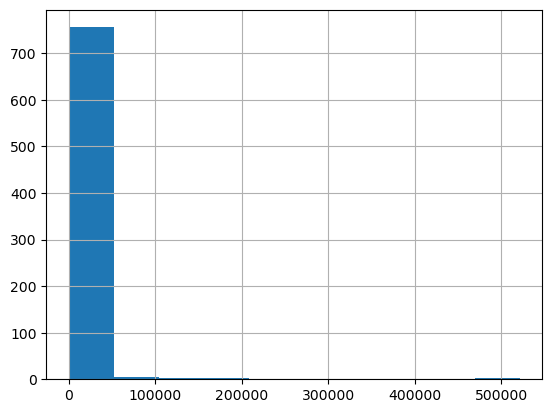

In [29]:
df['cite_count'].hist()

<Axes: >

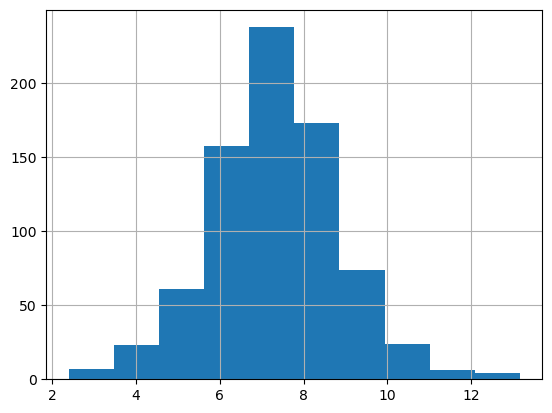

In [30]:
import numpy as np
df['log_cite_count'] = np.log(df['cite_count'])
df['log_cite_count'].hist()

Save what we have done so far.

In [31]:
df.to_pickle('sc_cases_cleaned.pkl',compression='gzip')
print(df)

                                             case_name opinion_type  \
345             JOHN F. HINCK, ET UX. v. UNITED STATES     majority   
696  ROBERT J. DEVLIN v. ROBERT A. SCARDELLETTI et al.     majority   
656  REMON LEE v. MIKE KEMNA, SUPERINTENDENT, CROSS...     majority   
549  CLACKAMAS GASTROENTEROLOGY ASSOCIATES, P. C. v...     majority   
790  NORFOLK SOUTHERN RAILWAY COMPANY v. DEDRA SHAN...     majority   
..                                                 ...          ...   
313                  PAT OSBORN v. BARRY HALEY, et al.     majority   
245      RICHARD WILL, et al. v. SUSAN HALLOCK, et al.     majority   
244  ALBERTO R. GONZALES, ATTORNEY GENERAL, et al. ...     majority   
438  DONALD C. WINTER, SECRETARY OF THE NAV., et al...     majority   
500  DISTRICT ATTORNEY'S OFFICE FOR THE THIRD JUDIC...     majority   

    date_standard authorship  x_republican  \
345    2007-05-21    ROBERTS           1.0   
696    2002-06-10   O'CONNOR           1.0   
656    20

## Iterating over documents in a dataframe

In the following, we show how to iterate over a dataframe and three different ways of how to tokenize documents.

In [32]:



import spacy


# more infos at https://spacy.io/
nlp = spacy.load('en_core_web_sm')

In [33]:
processed = {} # empty python dictionary for processed data
# iterate over rows
for i, row in df.iterrows():
    if i >= 10:
        break
    docid = i # make document identifier
    text = row['opinion_text']     # get text snippet
    document = nlp(text) # get sentences/tokens
    processed[docid] = document # add to dictionary    

In [35]:
# first and second opinions
print ("opinion 1:", processed[0][:50], "\n\n", "opinion 2:", processed[1][:50])

KeyError: 0

Let's see in more detail what information we can extract from documents procesesd using spaCy: 

In [36]:
for token in processed[0][:50]:
       print(token.text, token.pos_, token.dep_)

KeyError: 0

alternatively, we can preprocess with gensim

In [24]:
from gensim.utils import simple_preprocess

processed = {} # empty python dictionary for processed data
# iterate over rows
for i, row in df.iterrows():
    docid = i # make document identifier
    text = row['opinion_text']     # get text snippet
    document = simple_preprocess(text) # get sentences/tokens
    processed[docid] = document # add to dictionary    
    if i > 100:
        break
# first and second opinions
print ("opinion 1:", processed[0][:50], "\n\n", "opinion 2:", processed[1][:50]) # note how simple preprocess drops punctuation

opinion 1: ['justice', 'ginsburg', 'delivered', 'the', 'opinion', 'of', 'the', 'court', 'motion', 'by', 'federal', 'prisoner', 'for', 'postconviction', 'relief', 'under', 'is', 'subject', 'to', 'one', 'year', 'time', 'limitation', 'that', 'generally', 'runs', 'from', 'the', 'date', 'on', 'which', 'the', 'judgment', 'of', 'conviction', 'becomes', 'final', 'this', 'case', 'concerns', 'the', 'starting', 'date', 'for', 'the', 'one', 'year', 'limitation', 'it', 'presents'] 

 opinion 2: ['justice', 'stevens', 'delivered', 'the', 'opinion', 'of', 'the', 'court', 'in', 'most', 'of', 'the', 'united', 'states', 'not', 'including', 'california', 'the', 'minimum', 'price', 'paid', 'to', 'dairy', 'farmers', 'producing', 'raw', 'milk', 'is', 'regulated', 'pursuant', 'to', 'federal', 'marketing', 'orders', 'those', 'orders', 'guarantee', 'uniform', 'price', 'for', 'the', 'producers', 'but', 'through', 'pooling', 'mechanisms', 'require', 'the', 'processors', 'of']


or with nltk

In [37]:
import nltk
nltk.download('punkt')
from nltk.tokenize import word_tokenize
processed = {} # empty python dictionary for processed data
# iterate over rows
for i, row in df.iterrows():
    docid = i # make document identifier
    text = row['opinion_text']     # get text snippet
    document = word_tokenize(text.lower()) # get sentences/tokens
    processed[docid] = document # add to dictionary    
    if i > 100:
        break
# first and second opinions
print ("opinion 1:", processed[0][:50], "\n\n", "opinion 2:", processed[1][:50]) # note that we just tokenize and keep all tokens


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


KeyError: 0

## Saving data

In [38]:
# save as python pickle
pd.to_pickle(processed, 'processed_corpus.pkl')
# delete it
import os 
os.remove('processed_corpus.pkl')

In [38]:
# Merging Data-frames Example
# Perform a left join:
# df_merged = pd.merge(df1,df2,on='id', how='left', validation='m:1')

# Web Scraping

## Downloading URL's

In [38]:
import urllib.request as urllib
import json, os
from dotenv import load_dotenv, find_dotenv

load_dotenv(find_dotenv(), override=True)  # override=True forces reload even if var already set
token = os.environ["COURTLISTENER_TOKEN"]

url = "https://www.courtlistener.com/api/rest/v4/opinions/1247973/"
req = urllib.Request(url, headers={"Authorization": f"Token {token}", "Accept": "application/json"})
data = json.loads(urllib.urlopen(req).read())
html = data["html_lawbox"]  # field with the case text

print(html[:400])
print()
print(html[-400:])
print()
print(len(html), "characters in string.")

<div>
<center><b>674 P.2d 345 (1983)</b></center>
<center><h1>The PEOPLE of the State of Colorado, Plaintiff-Appellant,<br>
v.<br>
Edward Berlin GERMANY, Defendant-Appellee.<br>
The PEOPLE of the State of Colorado, Plaintiff-Appellant,<br>
v.<br>
James A. CHILDS, Defendant-Appellee.<br>
The PEOPLE of the State of Colorado, Plaintiff-Appellant,<br>
v.<br>
Megual Mariano TRUJILLO, Defendant-Appellee

908 (1963), applied retroactively in <i>McNerlin v. Denno,</i> 378 U.S. 575, 84 S.Ct. 1933, 12 L.Ed.2d 1041 (1964); double jeopardy bar against state and municipal prosecutions based upon the same act or offense, <i>Waller v. Florida,</i> 397 U.S. 387, 90 S.Ct. 1184, 25 L.Ed. 435 (1970), applied retroactively in <i>Robinson v. Neil,</i> 409 U.S. 505, 93 S.Ct. 876, 35 L.Ed.2d 29 (1973).</p>

</div>

36192 characters in string.


## Parsing HTML

In [39]:
# Parse raw HTML
# !pip install beautifulsoup4
from bs4 import BeautifulSoup # package for parsing HTML
soup = BeautifulSoup(html, 'lxml') # parse html of web page
print(soup.title) # example usage: print title item

NameError: name 'html' is not defined

In [40]:
# extract text
text = soup.get_text() # get text (remove HTML markup)
lines = text.splitlines() # split string into separate lines
print(len(lines)) # print number of lines

NameError: name 'soup' is not defined

In [41]:
lines = [line for line in lines if line != ''] # drop empty lines
print(len(lines)) # print number of lines

77


In [42]:
print(lines[:20]) # print first 20 lines

['674 P.2d 345 (1983)', 'The PEOPLE of the State of Colorado, Plaintiff-Appellant,', 'v.', 'Edward Berlin GERMANY, Defendant-Appellee.', 'The PEOPLE of the State of Colorado, Plaintiff-Appellant,', 'v.', 'James A. CHILDS, Defendant-Appellee.', 'The PEOPLE of the State of Colorado, Plaintiff-Appellant,', 'v.', 'Megual Mariano TRUJILLO, Defendant-Appellee.', 'The PEOPLE of the State of Colorado, Plaintiff-Appellant,', 'v.', 'Richard A. DURAN, Defendant-Appellee.', 'The PEOPLE of the State of Colorado, Plaintiff-Appellant,', 'v.', 'Dennis BANG, Defendant-Appellee.', 'Nos. 81SA559, 82SA189, 82SA240, 82SA260 and 82SA526.', 'Supreme Court of Colorado, En Banc.', 'November 15, 1983.', '*346 Norman S. Early, Jr., Dist. Atty., O. Otto Moore, Asst. Dist. Atty., William P. Buckley, Chief Deputy District Atty., Brooke Wunnicke, Chief Appellate Deputy Dist. Atty., Denver, for plaintiff-appellant in Nos. 81SA559 and 82SA189.']


## Removing unicode characters

In [41]:
!pip install unidecode
from unidecode import unidecode # package for removing unicode
uncode_str = 'Visualizations\xa0'
fixed = unidecode(uncode_str) # example usage
print([uncode_str],[fixed]) # print cleaned string (replaced with a space)

['Visualizations\xa0'] ['Visualizations ']


# Quantity of Text

Count words per document.

<Axes: >

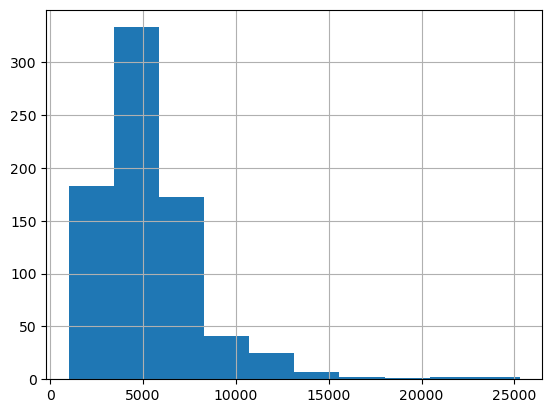

In [42]:
def get_words_per_doc(txt):
    # split text into words and count them.
    return len(txt.split()) 

# apply to our dataframe
df['num_words'] = df['opinion_text'].apply(get_words_per_doc)
df['num_words'].hist()

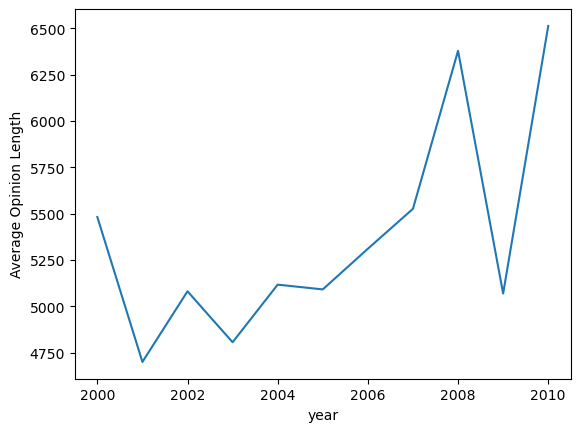

In [45]:
# plot length by year
ax = df.groupby('year')['num_words'].mean().plot()
ax.set_ylabel('Average Opinion Length')
import matplotlib.pyplot as plt
plt.show()

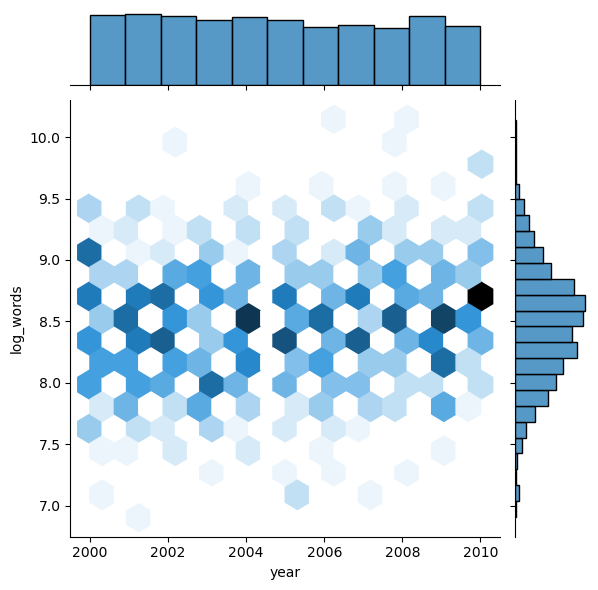

In [46]:
df['log_words'] = np.log(df['num_words'])
import seaborn as sns
sns.jointplot(data=df,x='year', y='log_words',kind='hex')

Build a frequency distribution over words with `Counter`.

In [43]:
from collections import Counter
freqs = Counter()
for i, row in df.iterrows():
    freqs.update(row['opinion_text'].lower().split())
    if i > 100:
        break
freqs.most_common()[:20] # can use most frequent words as style/function words

[('the', 151),
 ('of', 92),
 ('to', 75),
 ('in', 48),
 ('§', 41),
 ('a', 39),
 ('that', 35),
 ('for', 31),
 ('and', 29),
 ('tax', 28),
 ('court', 22),
 ('is', 19),
 ('or', 19),
 ('review', 19),
 ('not', 18),
 ('interest', 17),
 ('6404(e)(1)', 16),
 ('v.', 16),
 ('s.', 16),
 ('ct.', 16)]

# Dictionary / Matching Methods

## Sentiment Analysis

In [44]:
!pip install spacytextblob
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
print (spacy.__version__)

3.8.14


In [45]:
# Dictionary-Based Sentiment Analysis
nltk.download('vader_lexicon')

# textblob sentiment analysis: https://github.com/sloria/TextBlob
# pip install spacytextblob

import spacy
from spacytextblob.spacytextblob import SpacyTextBlob


nlp = spacy.load('en_core_web_sm')
# spacy_text_blob = SpacyTextBlob()
nlp.add_pipe('spacytextblob')
doc = nlp(df.iloc[0]["opinion_text"])
#from nltk.sentiment.vader import SentimentIntensityAnalyzer
#sid = SentimentIntensityAnalyzer()
#polarity = sid.polarity_scores(text)
print("polarity", doc._.blob.sentiment.polarity) # sentimentintensityanalayzer nltk: {'neg': 0.134, 'neu': 0.785, 'pos': 0.081, 'compound': -0.9999}
print ("subjectivity", doc._.blob.sentiment.subjectivity)

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


polarity 0.06987847222222221
subjectivity 0.4150049603174605


In [46]:
# sample 10% of the dataset
dfs = df.sample(frac=.1) 
# apply compound sentiment score to data-frame
def get_sentiment(snippet):
    #return sid.polarity_scores(snippet)['compound']
    return nlp(snippet)._.blob.sentiment.polarity
dfs['sentiment'] = dfs['opinion_text'].apply(get_sentiment)

In [52]:
dfs.sort_values('sentiment',inplace=True)
# print beginning of most positive documents
[x[50:150] for x  in dfs[-5:]['opinion_text']]

[' \n\n This case presents the question whether uses of patented inventions in preclinical research, the',
 't. \n\n This case requires us to decide whether the use of race as a factor in student admissions by t',
 ' \n\n  The State of Washington prohibits labor unions from using the agency-shop fees of a nonmember f',
 ' \n\n The question is whether the provision of the Fair Labor Standards Act of 1938 (FLSA or Act), tha',
 "t. \n\n We granted certiorari to resolve whether the Nevada Supreme Court's refusal to extend full fai"]

In [53]:
# print beginning of most negative documents
[x[50:150] for x  in dfs[:5]['opinion_text']]

['\n\nThe False Claims Act (FCA) imposes civil liability on any person who knowingly uses a "false recor',
 ' \n\nWhen an alien is found ineligible to remain in the United States, the process for selecting the c',
 'he Court. \n\n Petitioner Josue Leocal, a Haitian citizen who is a lawful permanent resident of the Un',
 " \n\n Respondent Arturo Recuenco was convicted of assault in the second degree based on the jury's fin",
 'he Court. \n\n InTotten v. United States,92 U.S. 105, 23 L. Ed. 605 (1876), we held that public policy']

In [54]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()
# sample 20% of the dataset
dfs = df.sample(frac=.1) 

# apply compound sentiment score to data-frame
def get_sentiment(snippet):
    return sid.polarity_scores(snippet)['compound']
dfs['sentiment_vader'] = dfs['opinion_text'].apply(get_sentiment)
dfs.sort_values('sentiment_vader',inplace=True)
# print beginning of most positive documents
[x[50:150] for x  in dfs[-5:]['opinion_text']]

[' Court. \n\n  Under the Internal Revenue Code, individuals may subtract from their adjusted gross inco',
 't and delivered an opinion, in which Justice Souter, Justice Ginsburg, and Justice Breyer join. \n\n T',
 '.\n\nA citizen of Hawaii comes before us claiming that an explicit, race-based voting qualification ha',
 't and delivered the opinion of the Court with respect to Parts I, II, III, and VI, an opinion with r',
 't. \n\n  For private actions brought under 42 U.S.C. § 1983 and other specified measures designed to s']

## Sentiment Analysis with Huggingface 

In [1]:
!pip install transformers
!pip install torch

from transformers import pipeline, AutoModelForTokenClassification, AutoTokenizer
pipe = pipeline("sentiment-analysis")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9614.45it/s]


In [4]:
from torch.utils.data import Dataset
from tqdm.auto import tqdm

class OpinionDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.df = df
    def __len__(self):
        return len(df)

    def __getitem__(self, i):
        return df.iloc[i]["opinion_text"][:512] # BERT max seq length


dataset = OpinionDataset(df)
sentiments = []

for out in tqdm(pipe(dataset, batch_size=16), total=len(dataset)):
        if out['label'] == "NEGATIVE":
            sentiments.append(-1*out['score'])
        else:
            sentiments.append(out['score'])

100%|██████████| 820/820 [00:07<00:00, 104.26it/s]


In [5]:
df['sentiments'] = sentiments

In [6]:
df.sort_values('sentiments',inplace=True)
# print beginning of most positive documents
[x[50:150] for x  in df[-5:]['opinion_text']]

['t. \n\n  The Federal Employees Liability Reform and Tort Compensation Act of 1988, commonly known as t',
 ' \n\n The authority of the Courts of Appeals to review "all final decisions of the district courts," 2',
 '. \n\n The question before us is whether the Controlled Substances Act allows the United States Attorn',
 ' Court.\n\n"To be prepared for war is one of the most effectual means of preserving peace." 1 Messages',
 ' Court. \n\nDNA testing has an unparalleled ability both to exonerate the wrongly convicted and to ide']

In [7]:
# print beginning of most negative documents
[x[50:150] for x  in df[:5]['opinion_text']]

["e of South Carolina and Rodger Stroup, the director of the State's Department of Archives and Histor",
 ' Court. \n\nBad things happen if you fail to pay federal income taxes when due. One of them is that in',
 ' motion to recuse in these cases consolidated below.  The motion is filed on behalf of respondent Si',
 'plication for a stay of orders of the Seventh Judicial Circuit Court of St. Johns County, Florida.  ',
 'Ohio voter who intervened in this case claimed that the Republican National Committee threatened to ']

## StopWords

In [8]:
#from nltk.corpus import stopwords
#stopwords = set(stopwords.words('english'))
#stopwords
from spacy.lang.en import stop_words
print(stop_words.STOP_WORDS)

{'enough', 'toward', 'himself', 'her', 'six', 'are', 'nobody', 'almost', 'a', 'been', 'herself', 'on', 'every', 'whether', 'yourselves', 'was', 'i', 'always', 'whereas', 'thus', 'here', 'nor', 'yours', 'latterly', 'latter', 'move', 'among', 'see', 'which', 'nevertheless', 'had', "'ll", 'after', 'could', 'afterwards', 'or', 'other', 'everywhere', 'each', 'since', 'around', 'below', 'off', 'from', '’ll', 'me', 'doing', 'nine', 'nowhere', 'with', 'none', 'others', 'eight', 'last', 'mostly', 'did', 'our', 'various', 'hundred', 'too', 'no', 'anyone', 'some', 'next', 'both', 'has', 'own', 'hereafter', 'sometimes', 'itself', 'he', 'someone', 'together', 'same', 'how', 'nothing', 'more', 'we', 'an', 'former', 'than', 'one', 'herein', 'between', 'perhaps', 'keep', 'ten', 'eleven', 'namely', 'all', '‘d', 'give', 'front', 'myself', 'though', 'per', 'of', 'whereafter', 'really', 'seeming', 'anywhere', 'rather', 'bottom', 'within', 'never', 'put', 'beyond', 'becoming', 'four', 'might', 'seems', 'yo

In [14]:
#stopfreq = np.sum([freqs[x] for x in stopwords])
#stopfreq # 174132 for NLTK stopwords
stopwords = stop_words.STOP_WORDS
stopfreq = np.sum([freqs[x] for x in stopwords])
stopfreq

np.int64(78)

In [15]:
otherfreq = np.sum([freqs[x] for x in freqs if x not in stopwords])
otherfreq

np.int64(107)

## RegEx

Please refer to [RegExOne Regular Expressions Lessons](regexone.com) and [the python documentation](https://docs.python.org/3/howto/regex.html).

In [47]:
import re

docs = dfs[:5]['opinion_text']

# Extract words after justice.
for doc in docs:    
    print(re.findall(r'Justice \w+ ', # pattern to match. always put 'r' in front of string so that backslashes are treated literally.
                     doc,            # string
                     re.IGNORECASE))  # ignore upper/lowercase (optional)

['Justice Ginsburg ']
['Justice Scalia ', 'Justice Alito ', 'Justice Breyer ', 'Justice Breyer ', 'Justice Breyer ', 'Justice Breyer ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice plurality ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Kennedy ', 'Justice Breyer ', 'Justice Stevens ']
['Justice Alito ', 'Justice and ', 'Justice Kennedy ', 'Justice Powell ', 'Justice Scalia ', 'Justice Scalia ']
['Justice Stevens ', 'justice that ']
['JUSTICE BREYER ']


In [48]:
# Extract hyphenated words
for doc in docs:    
    print(re.findall(r'[a-z]+-[a-z]+', 
                     doc,            
                     re.IGNORECASE))  

['heavy-duty', 'Reeder-Simco', 'Robinson-Patman', 'Robinson-Patman', 'Robinson-Patman', 'Robinson-Patman', 'customer-specific', 'heavy-duty', 'heavy-duty', 'five-year', 'one-year', 'customer-specific', 'case-by', 'industry-wide', 'Robinson-Patman', 'vice-president', 'five-year', 'non-Volvo', 'non-Volvo', 'non-Volvo', 'non-Volvo', 'vice-president', 'Robinson-Patman', 'state-law', 'Robinson-Patman', 'Robinson-Patman', 'Robinson-Patman', 'Robinson-Patman', 'heavy-duty', 'special-order', 'pre-identified', 'secondary-line', 'Robinson-Patman', 'price-cutting', 'Anheuser-Busch', 'Robinson-Patman', 'Robinson-Patman', 'Robinson-Patman', 'Robinson-Patman', 'Primary-line', 'Secondary-line', 'Tertiary-line', 'secondary-line', 'non-Volvo', 'purchase-to', 'non-Volvo', 'offer-to', 'head-to', 'Robinson-Patman', 'purchase-to', 'offer-to', 'vis-a', 'non-Volvo', 'non-Volvo', 'mix-and', 'vis-a', 'Robinson-Patman', 'customer-tailored', 'purchase-to', 'offer-to', 'Robinson-Patman', 'special-order', 'head-to

In [49]:
# extract citations
for i, doc in enumerate(docs):
    finder = re.finditer('\d+ [^\s]+ \d+', # pattern to match ([^\s] means non-white-space)
                     doc)            # string
    for m in finder: 
        print(i, m.span(),m.group()) # location (start,end) and matching string

0 (886, 898) 38 Stat. 730
0 (960, 973) 49 Stat. 1526
0 (2163, 2175) 374 F.3d 701
0 (2177, 2190) 704 (CA8 2004
0 (3716, 3728) 374 F.3d 701
0 (3734, 3747) 705 (CA8 2004
0 (4555, 4565) 4 id. 1161
0 (4904, 4913) 146 to 75
0 (10185, 10197) 842 F.2d 578
0 (10199, 10212) 585 (CA2 1987
0 (12118, 12130) 544 U.S. 903
0 (12878, 12890) 363 U.S. 536
0 (14357, 14369) 451 U.S. 557
0 (14698, 14710) 509 U.S. 209
0 (15633, 15645) 496 U.S. 543
0 (16923, 16935) 371 U.S. 505
0 (17117, 17129) 460 U.S. 428
0 (17482, 17493) 334 U.S. 37
0 (17533, 17547) 44 F.T.C. 1499
0 (22802, 22816) 26 (quoting 15
0 (24588, 24599) 433 U.S. 36
0 (26362, 26373) 440 U.S. 69
0 (26472, 26483) 346 U.S. 61
0 (26521, 26535) 49 F.T.C. 1763
1 (498, 510) 512 U.S. 374
1 (672, 684) 524 U.S. 156
1 (839, 851) 243 U.S. 316
1 (960, 972) 168 U.S. 349
1 (1256, 1267) 58 Fla. 398
1 (1278, 1288) 50 So. 826
1 (1764, 1773) 998 So. 2
1 (1975, 1987) 141 Fla. 452
1 (1998, 2009) 193 So. 425
1 (2381, 2391) 75 Fla. 28
1 (2401, 2411) 78 So. 491
1 (2777, 2

In [50]:
# baker-bloom economic uncertainty
pattern1 = r'(\b)uncertain[a-z]*'
pattern2 = r'(\b)econom[a-z]*'
pattern3 = r'(\b)congress(\b)|(\b)deficit(\b)|(\b)federal reserve(\b)|(\b)legislation(\b)|(\b)regulation(\b)|(\b)white house(\b)'



In [51]:
re.search(pattern1,'The White House tried to calm uncertainty in the markets.')

<re.Match object; span=(30, 41), match='uncertainty'>

In [52]:
re.search(pattern2,'The Congress tried to calm uncertainty in the economy.')

<re.Match object; span=(46, 53), match='economy'>

In [53]:
re.search(pattern3,'The Congress tried to calm uncertainty in the markets.')

In [54]:
re.search(pattern3,'The Congress tried to calm uncertainty in the markets.', re.IGNORECASE)

<re.Match object; span=(4, 12), match='Congress'>

In [55]:
def indicates_uncertainty(doc):
    m1 = re.search(pattern1, doc, re.IGNORECASE)
    m2 = re.search(pattern2, doc, re.IGNORECASE)
    m3 = re.search(pattern3, doc, re.IGNORECASE)
    if m1 and m2 and m3:
        return True
    else:
        return False

In [56]:
indicates_uncertainty('The White House tried to calm uncertainty in the economy.')

True

In [57]:
indicates_uncertainty('The White House tried to calm uncertainty in the markets.')

False

In [58]:
df['uncertainty'] = df['opinion_text'].apply(indicates_uncertainty)

In [59]:
df.uncertainty.mean()

np.float64(0.057291666666666664)

<Axes: xlabel='year'>

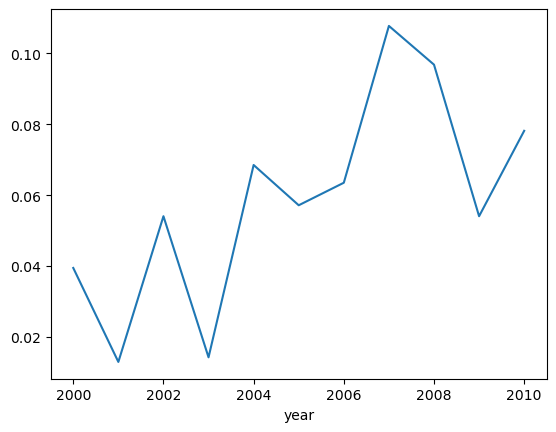

In [60]:
df.groupby('year')['uncertainty'].mean().plot()

## WordNet

These examples are based on the [NLTK tutorial](https://www.nltk.org/howto/wordnet.html).

In [61]:
nltk.download('wordnet')
from nltk.corpus import wordnet as wn

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joshuaberry/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [62]:
nltk.download('omw-1.4')
wn.synsets('judge')

[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/joshuaberry/nltk_data...


[Synset('judge.n.01'),
 Synset('evaluator.n.01'),
 Synset('judge.v.01'),
 Synset('evaluate.v.02'),
 Synset('estimate.v.01'),
 Synset('pronounce.v.02'),
 Synset('judge.v.05')]

In [63]:
wn.synsets('judge', pos='v') # can filter on part of speech

[Synset('judge.v.01'),
 Synset('evaluate.v.02'),
 Synset('estimate.v.01'),
 Synset('pronounce.v.02'),
 Synset('judge.v.05')]

In [64]:
judge = wn.synset('judge.n.01')
judge

Synset('judge.n.01')

In [65]:
judge.definition()

'a public official authorized to decide questions brought before a court of justice'

In [66]:
wn.synset('estimate.v.01').examples()

['I estimate this chicken to weigh three pounds']

In [67]:
# categories to which "judge.n.01" belongs
judge.hypernyms()

[Synset('official.n.01'), Synset('adjudicator.n.01')]

In [91]:
# the root category of "judge.n.01"
judge.root_hypernyms()

[Synset('entity.n.01')]

In [68]:
wn.synset('estimate.v.01').root_hypernyms()

[Synset('think.v.03')]

In [69]:
# members of the "judge.n.01" category
judge.hyponyms()

[Synset('recorder.n.03'),
 Synset('chief_justice.n.01'),
 Synset('praetor.n.01'),
 Synset('qadi.n.01'),
 Synset('ordinary.n.01'),
 Synset('magistrate.n.01'),
 Synset('daniel.n.02'),
 Synset('alcalde.n.01'),
 Synset('trial_judge.n.01'),
 Synset('doge.n.01'),
 Synset('justiciar.n.01'),
 Synset('trier.n.01')]

In [70]:
# "holonym" is a part of a whole
juror = wn.synset('juror.n.01')
juror.member_holonyms()

[Synset('jury.n.01')]

In [71]:
# can find "lowest common hypernyms":
judge.lowest_common_hypernyms(juror)

[Synset('person.n.01')]

In [72]:
# "lemmas" are specific senses of a specific word.
judge.lemmas()

[Lemma('judge.n.01.judge'),
 Lemma('judge.n.01.justice'),
 Lemma('judge.n.01.jurist')]

In [73]:
[lemma.name() for lemma in judge.lemmas()]

['judge', 'justice', 'jurist']

In [98]:
# lemmas have additional properties
judge_lemma = judge.lemmas()[0]
judge_lemma.derivationally_related_forms()

[Lemma('judicial.s.01.judicial'),
 Lemma('judicial.a.02.judicial'),
 Lemma('judicial.a.03.judicial'),
 Lemma('judgeship.n.01.judgeship'),
 Lemma('judge.v.05.judge'),
 Lemma('judge.v.05.adjudicate'),
 Lemma('decide.v.02.adjudicate')]

In [74]:
good = wn.synset('good.a.01').lemmas()[0]
good.antonyms()

[Lemma('bad.a.01.bad')]

In [75]:
# verb frames summarize the different semantic contexts that a verb can be used
judge_verb = wn.synset('estimate.v.01').lemmas()[4]
judge_verb.frame_strings()

['Somebody judge something', 'Somebody judge PP', 'Somebody judge that CLAUSE']

In [76]:
# measure similarity in the dictionary between words
judge.path_similarity(wn.synset('juror.n.01'))

0.1111111111111111

In [77]:
judge.path_similarity(wn.synset('cat.n.01'))

0.08333333333333333

In [78]:
# Wu-Palmer similarity.
judge.wup_similarity(juror)

0.5454545454545454

In [79]:
judge.wup_similarity(wn.synset('cat.n.01'))

0.5217391304347826

In [80]:
# Can iterate over all synsets; e.g., all nouns:
for synset in list(wn.all_synsets('n')):
    if 'judg' in str(synset):
        print(synset)

Synset('judgeship.n.01')
Synset('judgment.n.02')
Synset('value_judgment.n.01')
Synset('judgment.n.03')
Synset('confession_of_judgment.n.01')
Synset('default_judgment.n.01')
Synset('final_judgment.n.01')
Synset('judgment_in_personam.n.01')
Synset('judgment_in_rem.n.01')
Synset('judgment_of_dismissal.n.01')
Synset('judgment_on_the_merits.n.01')
Synset('summary_judgment.n.01')
Synset('judgment.n.06')
Synset('judgment.n.04')
Synset('prejudgment.n.01')
Synset('judgment.n.01')
Synset('judges.n.01')
Synset('back_judge.n.01')
Synset('field_judge.n.01')
Synset('judge.n.01')
Synset('judge_advocate.n.02')
Synset('judge_advocate.n.01')
Synset('judge_advocate_general.n.01')
Synset('line_judge.n.01')
Synset('side_judge.n.01')
Synset('trial_judge.n.01')
Synset('judgment_lien.n.01')
Synset('judgment_day.n.01')


**Exercise**. Use wordnet to expand the set of words in the Baker-Bloom-Davis dictionary and re-compute policy uncertainty scores by year. 

Uncertainty synonyms: ['changeable', 'doubt', 'doubtfulness', 'dubiety', 'dubiousness', 'incertain', 'incertitude', 'precariousness', 'uncertain', 'uncertainness', 'uncertainty', 'unsealed', 'unsettled', 'unsure']

Economy synonyms: ['economic', 'economic system', 'economical', 'economy', 'saving', 'thriftiness']

Policy synonyms: ['carnal knowledge', 'coition', 'coitus', 'congress', 'copulation', 'deficit', 'federal reserve', 'intercourse', 'lawmaking', 'legislating', 'legislation', 'ordinance', 'regularisation', 'regularization', 'regulating', 'regulation', 'relation', 'rule', 'sex act', 'sexual congress', 'sexual intercourse', 'sexual relation', 'shortage', 'shortfall', 'statute law', 'u.s. congress', 'united states congress', 'us congress', 'white house']


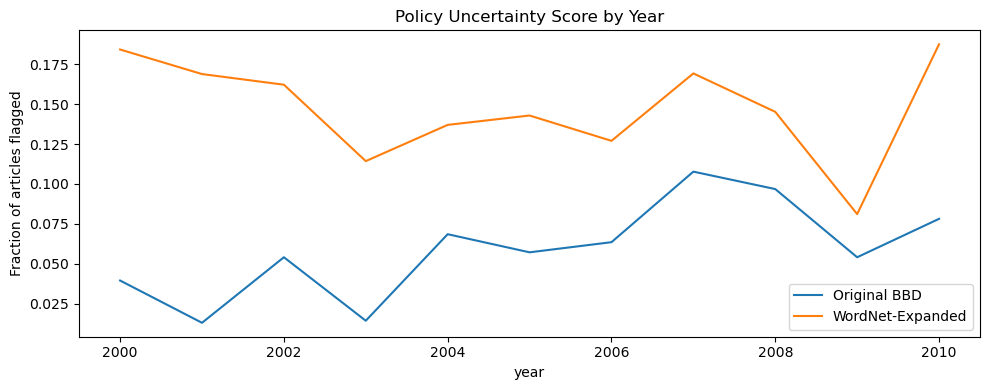

Overall mean — original: 0.0573  expanded: 0.1471


In [81]:
# --- Step 1: Use WordNet to expand each BBD word category ---

def get_synonyms(seed_words, pos=None):
    """Return all lemma names across all synsets for a list of seed words."""
    synonyms = set()
    for word in seed_words:
        for synset in wn.synsets(word, pos=pos):
            for lemma in synset.lemmas():
                synonyms.add(lemma.name().replace('_', ' ').lower())
    return synonyms

# Category 1: uncertainty words (adjective + noun forms)
uncertain_words = (get_synonyms(['uncertain', 'uncertainty'], pos='a')
                 | get_synonyms(['uncertain', 'uncertainty'], pos='s')
                 | get_synonyms(['uncertainty'], pos='n'))
print("Uncertainty synonyms:", sorted(uncertain_words))

# Category 2: economy / economic words
economy_words = (get_synonyms(['economy', 'economic'], pos='n')
               | get_synonyms(['economic'], pos='a'))
print("\nEconomy synonyms:", sorted(economy_words))

# Category 3: policy / legislative words
policy_seed = ['congress', 'deficit', 'legislation', 'regulation']
policy_words = get_synonyms(policy_seed, pos='n')
policy_words.update(['federal reserve', 'white house'])   # keep fixed phrases
print("\nPolicy synonyms:", sorted(policy_words))

# --- Step 2: Build expanded regex patterns ---
import re

def words_to_pattern(words):
    # longer phrases first so they match before their sub-strings
    sorted_words = sorted(words, key=len, reverse=True)
    return r'\b(?:' + '|'.join(re.escape(w) for w in sorted_words) + r')\b'

pattern1_exp = words_to_pattern(uncertain_words)
pattern2_exp = words_to_pattern(economy_words)
pattern3_exp = words_to_pattern(policy_words)

# --- Step 3: Recompute policy uncertainty with the expanded dictionary ---

def indicates_uncertainty_exp(doc):
    m1 = re.search(pattern1_exp, doc, re.IGNORECASE)
    m2 = re.search(pattern2_exp, doc, re.IGNORECASE)
    m3 = re.search(pattern3_exp, doc, re.IGNORECASE)
    return bool(m1 and m2 and m3)

df['uncertainty_exp'] = df['opinion_text'].apply(indicates_uncertainty_exp)

# --- Step 4: Compare original vs. expanded scores by year ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
df.groupby('year')['uncertainty'].mean().plot(ax=ax, label='Original BBD')
df.groupby('year')['uncertainty_exp'].mean().plot(ax=ax, label='WordNet-Expanded')
ax.set_ylabel('Fraction of articles flagged')
ax.set_title('Policy Uncertainty Score by Year')
ax.legend()
plt.tight_layout()
plt.show()
print("Overall mean — original:", df.uncertainty.mean().round(4),
      " expanded:", df.uncertainty_exp.mean().round(4))
